https://snap.stanford.edu/data/egonets-Facebook.html

https://networkx.org/nx-guides/content/exploratory_notebooks/facebook_notebook.html

https://nurturenaturecenter.org/6-degrees-of-connection-understanding-the-interconnectedness-of-earth-systems/#:~:text=A%20personal%20relevance%20approach%20makes,of%20the%20different%20earth%20systems.

In [181]:
from google.colab import drive
drive.mount('/content/drive')
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [182]:
path = "/content/drive/MyDrive/facebook_combined.txt.gz"
facebook = pd.read_csv(
    path,
    compression="gzip",
    sep=" ",
    names=["start_node", "end_node"],
)
real_G = nx.from_pandas_edgelist(facebook, "start_node", "end_node")

pos = nx.spring_layout(real_G, iterations=15, seed=1721)


def graph_no_details(G):
  fig, ax = plt.subplots(figsize=(15, 9))
  ax.axis("off")
  nx.draw_networkx(G, pos=pos, ax=ax, node_size=10, with_labels=False, width=0.05)


def graph_details(G):
  fig, ax = plt.subplots(figsize=(15, 9))
  ax.axis("off")
  node_size = [v * 500 for v in nx.degree_centrality(G).values()]

  degrees = dict(G.degree())

  # Identify the top 10 nodes with the highest degrees
  top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:10]
  bridges = list(nx.bridges(G))
  local_bridges = [local_bridge for local_bridge in nx.local_bridges(G, with_span=False) if local_bridge not in bridges]

  nx.draw_networkx_edges(G, pos, edgelist=local_bridges, width=0.75, edge_color="red")  # red color for local bridges
  nx.draw_networkx_edges(G, pos, edgelist=bridges, width=0.25, edge_color="green")  # green color for bridges

  # Assign colors to nodes
  node_colors = ["red" if node in top_nodes else "blue" for node in G.nodes()]
  nx.draw_networkx(G, pos=pos, ax=ax, node_size=node_size, with_labels=False, width=0.03, node_color=node_colors)


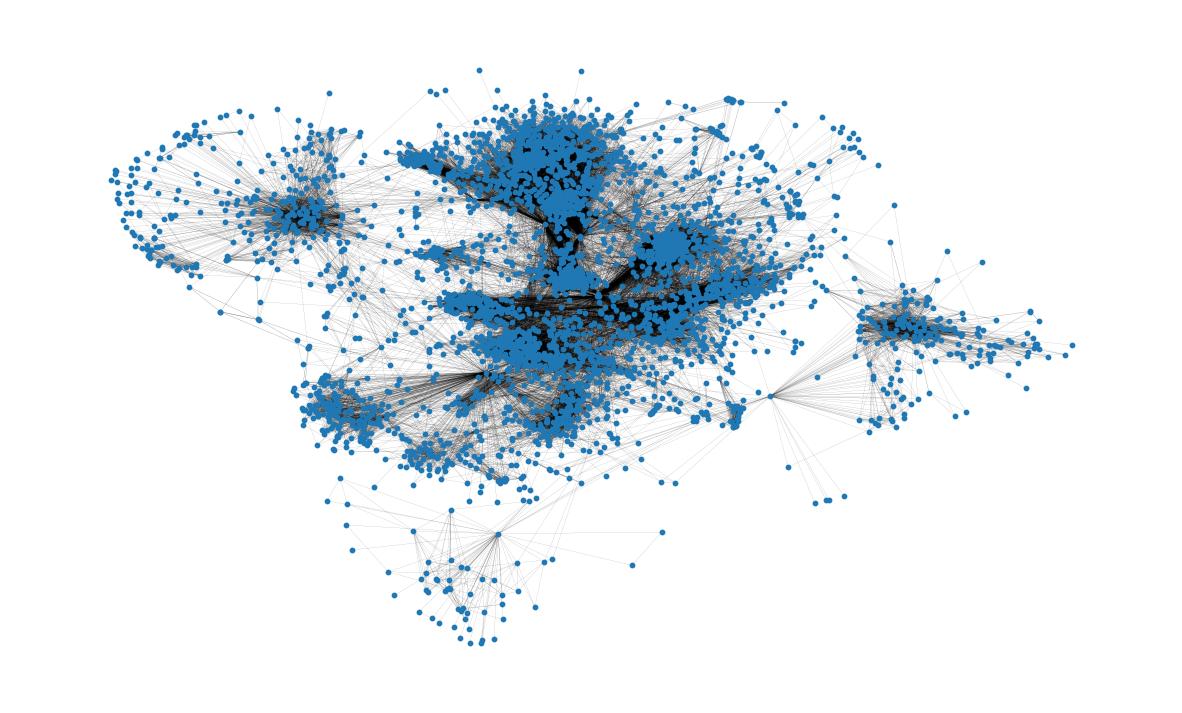

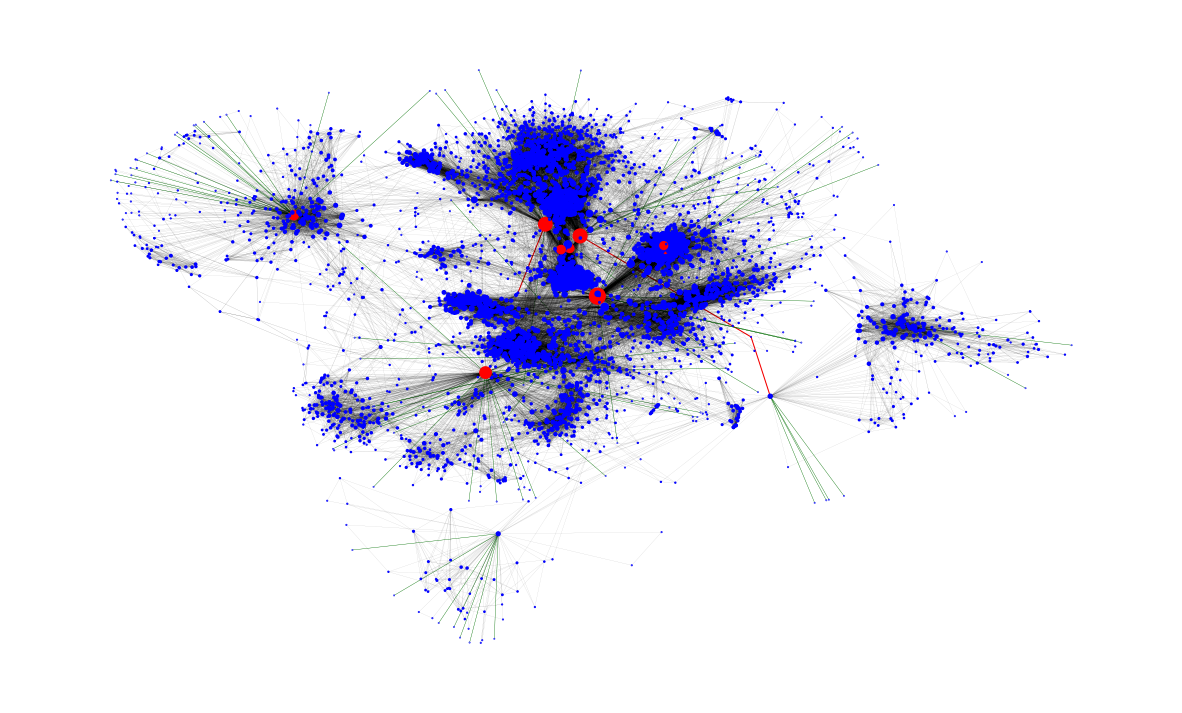

In [183]:
graph_no_details(real_G)
graph_details(real_G)

In [184]:
def get_metrics(G):
  print(f"Average Clustering Coefficient: {nx.average_clustering(G)}") #How many people in your mutual friends list are you connected to/the total number possible

  local_bridges = len(list(nx.local_bridges(G, with_span=False)))
  print(f"Number of Local Bridges: {local_bridges}") #Connections that if lost, would make the bridge between two communities much longer. Think Spanish American Singers

  connected = nx.number_connected_components(G)
  print(f"Number of Separate Connected Components: {connected}") #How many communities (parts of the graph where everyone is connected) are there

  density = nx.density(G)
  print(f"Density: {density}") #How tightly knit the graph is: (2*Num_Edges)/(Num_Nodes*(Num_Nodes-1))
  #How many friendships are there compared to the total number of potential friendships

  if connected == 1:
    diameter = nx.diameter(G)#In real world social networks today, this number is 6. So your (friend's)*5 friend is anyone in the world
    print(f"Longest shortest path between two people: {diameter}")
    average_shortest_path_length = nx.average_shortest_path_length(G)
    print(f"Average shortest path between two people for every pair of people in the network: {average_shortest_path_length}")
  #In a directed graph (one way connections like "followers" on Instagram, this number is even lower)
  else:
    print("No Global Diameter or average shortest paths. Graph not fully connected")

  print('\n')


get_metrics(real_G)

Average Clustering Coefficient: 0.6055467186200876
Number of Local Bridges: 78
Number of Separate Connected Components: 1
Density: 0.010819963503439287
Longest shortest path between two people: 8
Average shortest path between two people for every pair of people in the network: 3.6925068496963913




      Betweenness Centrality
1418                0.000003
3645                0.000003
1240                0.000003
2620                0.000003
1942                0.000003
...                      ...
1085                0.149015
1912                0.229295
3437                0.236115
1684                0.337797
107                 0.480518

[2020 rows x 1 columns]
      Betweenness Centrality
873                 0.000000
2375                0.000000
2380                0.000000
2382                0.000000
2431                0.000000
...                      ...
2057                0.000003
2074                0.000003
2815                0.000003
1441                0.000003
1737                0.000003

[2019 rows x 1 columns]
Removing the Bottom 50% of Nodes by Degree
Average Clustering Coefficient: 0.5870361942984154
Number of Local Bridges: 5
Number of Separate Connected Components: 1
Density: 0.02907772203669104
Longest shortest path between two people: 8
Average shortest 

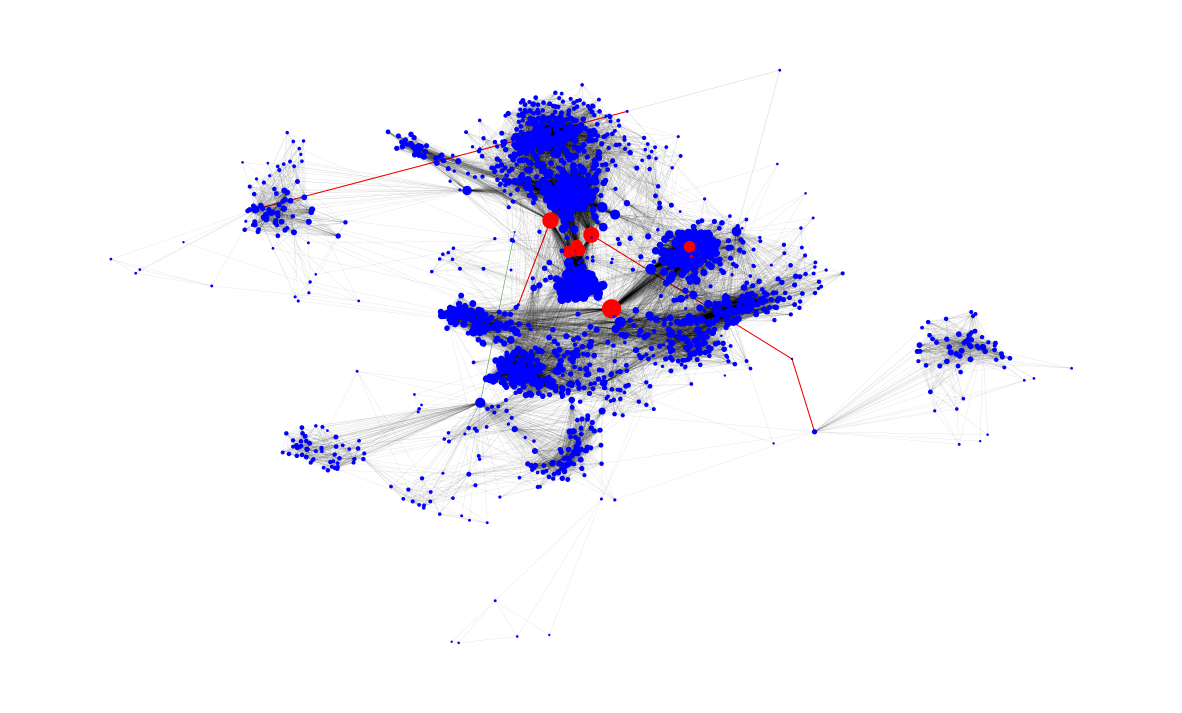

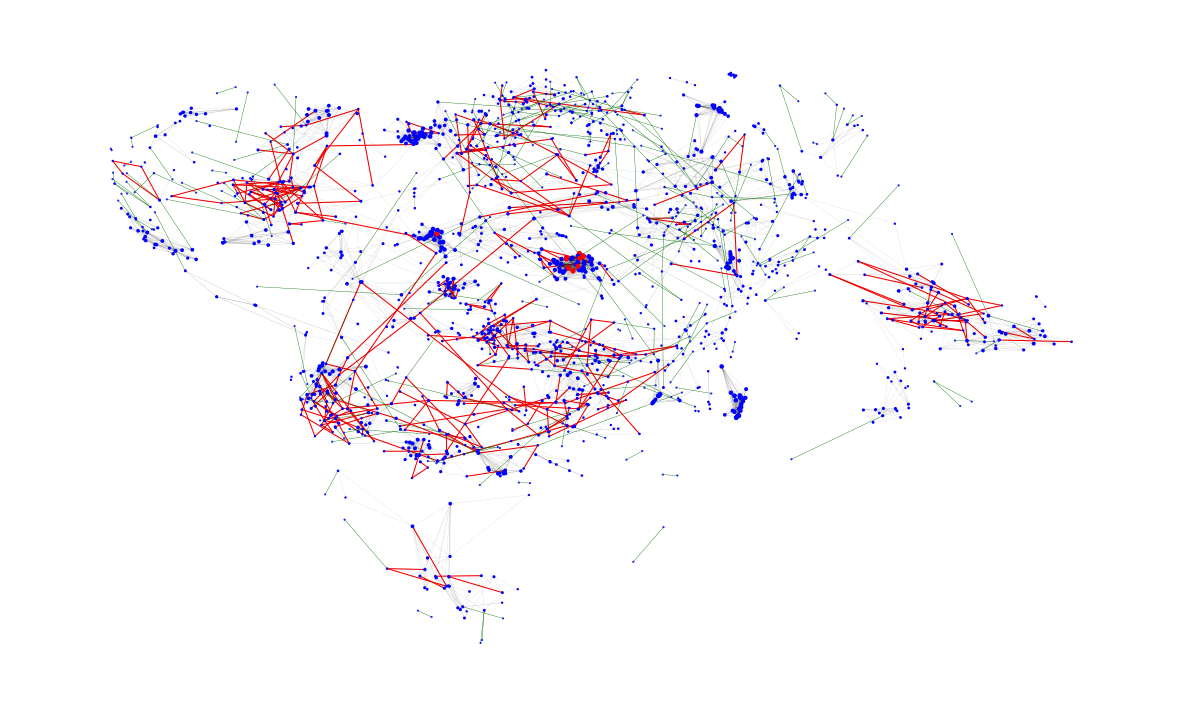

In [185]:
#node_df = pd.DataFrame(index=real_G.nodes())
#node_df["Betweenness Centrality"] = nx.betweenness_centrality(real_G, endpoints=False)

top_half_tie_strength = node_df.sort_values("Betweenness Centrality").iloc[int(len(node_df)/2):,:]
print(top_half_tie_strength)
bottom_half_tie_strength = node_df.sort_values("Betweenness Centrality").iloc[:int(len(node_df)/2),:]
print(bottom_half_tie_strength)

G_top = real_G.subgraph(list(top_half_tie_strength.index)).copy()
G_bottom = real_G.subgraph(list(bottom_half_tie_strength.index)).copy()
#pos = nx.spring_layout(real_G, iterations=15, seed=1721)
print("Removing the Bottom 50% of Nodes by Degree")
get_metrics(G_top)
graph_details(G_top)

print("Removing the top 50% of Nodes by Degree")
get_metrics(G_bottom)
graph_details(G_bottom)

BOB: {'email': 'bob@gmail.com', 'country': 'AUS', 'dob': 'Jun-30-1988', 'groups_followed': ['Photography Enthusiasts', 'Gaming Community', 'Travel Lovers', 'Book Club', 'Tech Enthusiasts', 'Music Fans', 'Fitness Freaks', 'Art and Design']}
BOB'S FRIENDS: ['Alice', 'Carol', 'Steve', 'Frank']


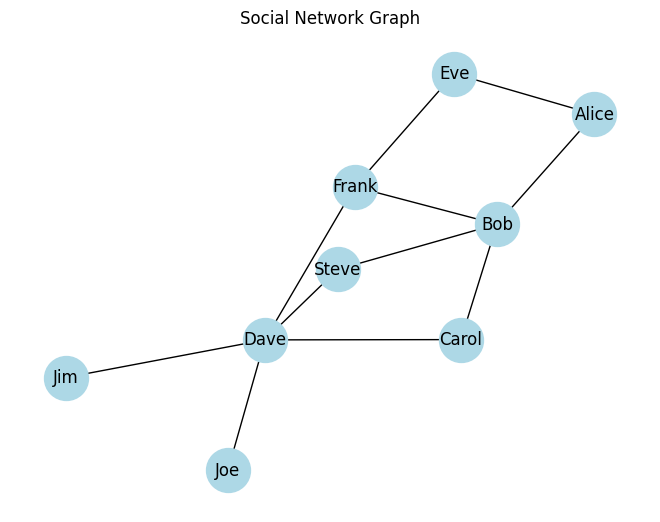

In [177]:
# Create an empty graph
simple_G = nx.Graph()

#Define your nodes (people in the network) here it is redundant because
#they are automatically defined when we list the edges after. But in
#some cases you want to define the nodes first like this.

nodes = ['Alice', 'Bob', 'Carol', 'Steve', 'Dave', 'Eve', 'Frank', 'Joe', 'Jim']

email_domains = ['gmail.com', 'yahoo.com', 'student.uml.edu']

country = ['USA', 'FRA', 'UK', 'AUS']

dob = ['May-15-1990', 'Sep-22-1985', 'Dec-03-1978', 'Mar-10-1995', 'Jul-18-1982', 'Nov-25-1998', 'Feb-08-1970', 'Jun-30-1988', 'Apr-14-1975']

groups_followed = ['Tech Enthusiasts', 'Book Club', 'Fitness Freaks', 'Travel Lovers', 'Photography Enthusiasts', 'Foodies', 'Music Fans', 'Art and Design', 'Gaming Community']



# Define the list of edges (also referred to as links or connections)
simple_edges = [
    ("Alice", "Bob"),
    ("Bob", "Carol"),
    ("Bob", "Steve"),
    ("Carol", "Dave"),
    ("Alice", "Eve"),
    ("Eve", "Frank"),
    ("Bob", "Frank"),
    ("Dave", "Frank"),
    ("Dave", "Joe"),
    ("Dave", "Jim"),
    ("Dave", "Steve")

]

# Add edges to the graph to represent the connections
simple_G.add_edges_from(simple_edges)

for node in nodes:
    # Assign random values to each attribute
    email = f"{node.lower()}@{random.choice(email_domains)}"
    country_value = random.choice(country)
    dob_value = random.choice(dob)
    groups_value = random.sample(groups_followed, k=np.random.randint(1, len(groups_followed)))

    # Assign attributes to the node
    attributes = {'email': email, 'country': country_value, 'dob': dob_value, 'groups_followed': groups_value}

    # Assuming you have a graph 'G' created using NetworkX
    simple_G.nodes[node].update(attributes)

user = "Bob"
print(f"{user.upper()}: {simple_G.nodes[user]}")
print(f"{user.upper()}'S FRIENDS: {list(simple_G[user])}")

# Draw the graph
pos = nx.spring_layout(simple_G, seed=42)  # Positions nodes nicely for visualization
nx.draw(simple_G, pos, with_labels=True, node_color='lightblue', node_size=1000)
plt.title("Social Network Graph")
plt.show()

In [ ]:
# Calculate and print node centralities, betweenness centralities, and closeness centralities
node_centralities = nx.degree_centrality(G)
betweenness_centralities = nx.betweenness_centrality(G)
closeness_centralities = nx.closeness_centrality(G)

# Sort the centralities and print the sorted lists
sorted_node_centralities = sorted(node_centralities.items(), key=lambda x: x[1], reverse=True)
sorted_betweenness_centralities = sorted(betweenness_centralities.items(), key=lambda x: x[1], reverse=True)
sorted_closeness_centralities = sorted(closeness_centralities.items(), key=lambda x: x[1], reverse=True)

print("Node Centralities (Normalized Number of Connections, for Dave: 5 Connections/8 Possible Connections):")
for node, centrality in sorted_node_centralities:
    print(f"{node}: {centrality}")

print("\nBetweenness Centralities (How often a node occurs on a path between two other node, Ex: How many people kind of know each other through Jim):")
for node, centrality in sorted_betweenness_centralities:
    print(f"{node}: {centrality}")

print("""\nCloseness Centralities (How close a node is to all other nodes.
Even if someone is not directly friends with everyone,is there a low number of
edges required to connect them to others):""")

for node, centrality in sorted_closeness_centralities:
    print(f"{node}: {centrality}")

Node Centralities (Normalized Number of Connections, for Dave: 5 Connections/8 Possible Connections):
Dave: 0.625
Bob: 0.5
Frank: 0.375
Alice: 0.25
Carol: 0.25
Steve: 0.25
Eve: 0.25
Joe: 0.125
Jim: 0.125

Betweenness Centralities (How often a node occurs on a path between two other node, Ex: How many people kind of know each other through Jim):
Dave: 0.5416666666666666
Bob: 0.2708333333333333
Frank: 0.2619047619047619
Carol: 0.0625
Steve: 0.0625
Eve: 0.04464285714285714
Alice: 0.04166666666666666
Joe: 0.0
Jim: 0.0

Closeness Centralities (How close a node is to all other nodes. 
Even if someone is not directly friends with everyone,is there a low number of 
edges required to connect them to others):
Dave: 0.6666666666666666
Frank: 0.6153846153846154
Bob: 0.5714285714285714
Carol: 0.5333333333333333
Steve: 0.5333333333333333
Eve: 0.4444444444444444
Alice: 0.42105263157894735
Joe: 0.42105263157894735
Jim: 0.42105263157894735


In [ ]:
# Perform a simple link prediction task
potential_links = []

# Iterate through all pairs of nodes
for node1 in G.nodes():
    for node2 in G.nodes():
        if node1 != node2 and not G.has_edge(node1, node2):
            # Check if the nodes share a common neighbor
            common_neighbors = list(nx.common_neighbors(G, node1, node2))
            if common_neighbors:
                potential_links.append((node1, node2))

# Print the potential links
#This is a very simple edge prediction task. It's basically how "mutual friend" predictions work with Facebook, IG, etc.
print("Potential links:")
for link in potential_links:
    print(link)

Potential links:
('Alice', 'Carol')
('Alice', 'Steve')
('Alice', 'Frank')
('Bob', 'Dave')
('Bob', 'Eve')
('Carol', 'Alice')
('Carol', 'Steve')
('Carol', 'Frank')
('Carol', 'Joe')
('Carol', 'Jim')
('Steve', 'Alice')
('Steve', 'Carol')
('Steve', 'Frank')
('Steve', 'Joe')
('Steve', 'Jim')
('Dave', 'Bob')
('Dave', 'Eve')
('Eve', 'Bob')
('Eve', 'Dave')
('Frank', 'Alice')
('Frank', 'Carol')
('Frank', 'Steve')
('Frank', 'Joe')
('Frank', 'Jim')
('Joe', 'Carol')
('Joe', 'Steve')
('Joe', 'Frank')
('Joe', 'Jim')
('Jim', 'Carol')
('Jim', 'Steve')
('Jim', 'Frank')
('Jim', 'Joe')


#TO DO:
##Importance of Weak Links and Relation to Network Design (Router Traffic)
##6 Links away from anyone in the world